# Application C — probability of a latency-budget violation

**Purpose:** Predict the probability that a request will exceed a latency budget
(a maximum acceptable response time), then decide when to raise an alarm.
This is **binary classification**: the outcome is either a violation, $y=1$, or no violation, $y=0$.
Unlike predicting a numerical latency, we predict a probability between zero and one.

There are two separate tasks: **learn probabilities from data** and **choose a decision rule**.
A request with predicted violation probability 0.30 may deserve an alarm even though a violation
is less likely than no violation, if missing a violation is sufficiently costly.

### Definitions used throughout

| Symbol or term | Meaning in this notebook |
| --- | --- |
| $s$, `payload` | Request payload size, in the simulation's chosen size units. |
| $q$, `queue` | Number of requests already queued at arrival. |
| $c$, `cache` | Cache-hit indicator: 1 for a hit, 0 otherwise; known at arrival. |
| $y$ | Observed outcome: 1 for a budget violation, 0 otherwise. |
| $z$ | A real-valued score, also called the log-odds; it is not a probability. |
| $\sigma(z)=1/(1+e^{-z})$ | The sigmoid function, which converts a score into a probability. |
| $\pi$ | The true violation probability used to generate simulated labels. |
| $p$ or $\hat p$ | The violation probability estimated by a fitted model. |
| $b$, $w_j$ | Learned intercept and feature coefficients in the model $z=b+\sum_j w_jx_j$. |
| $\beta$ (`beta`) | A vector collecting an intercept and coefficients; in the implementation it uses standardized features. |
| $\lambda$ (`penalty`) | Nonnegative regularization strength: larger values penalize large slope coefficients more strongly. |
| $t$ (`threshold`) | Alarm cutoff: predict a violation when $\hat p\ge t$. |

**Cross-validation (CV)** repeatedly fits models on part of the training data and scores them
on held-out training rows. Five-fold cross-validation uses five groups of rows, holding out
each group once. Here it selects the regularization strength, not the alarm threshold.
**Gradient descent (GD)** is an iterative method for learning coefficients by reducing a loss function.
A **loss** measures how poor a prediction is; lower loss is better.

### What happens in this notebook?

1. Generate 2,000 synthetic requests and reserve training, validation, and test data.
2. Implement logistic loss and check its mathematical derivative.
3. Fit an unpenalized model by gradient descent and compare it with scikit-learn.
4. Interpret its coefficients using odds.
5. Use training cross-validation to select regularization and fit the selected model.
6. Use validation data to choose an alarm threshold under stated error costs.
7. Evaluate the fixed model and decision rules on the test data.
8. Inspect whether probabilities match observed frequencies and how alarm tradeoffs vary.

The manual fit in Sections 2–4 teaches how logistic regression works. Section 5 then chooses
the model used for decisions. The data split is **60/20/20**: 1,200 training rows, 400 validation
rows, and 400 test rows. Test results are not used to change the model or its threshold.

### Python model methods

`LogisticRegression(...)` creates a model object with chosen settings. `.fit(X, y)` learns
coefficients; `.predict_proba(X_new)` returns two columns, the probabilities of classes 0 and 1.
For our labels, `[:, 1]` selects the violation probability. `.predict(X_new)` returns class labels
using the model's default decision rule. We instead compare probabilities with an explicit
threshold so that our alarm policy can account for unequal error costs.

The library parameter `C` controls the **inverse** strength of regularization; it is not
cross-validation and is unrelated to the application letter C. Section 5 explains its
conversion from our mathematical $\lambda$.

Run cells in order with the course dependencies in `../requirements.txt` (tested with scikit-learn 1.8).
See [the focused guide](01_linear_and_logistic_regression.pdf). All data are generated here;
no data download or notebook A is needed.

## 1. Generate independent arrivals and reserve stratified partitions

**Task:** Create data for which the true probability is known, while keeping that information
out of the model inputs. For each of 2,000 independent arrivals, generate independent features:

- $s\sim U(0.5,10)$: payload is uniform between 0.5 and 10.
- $q\sim\operatorname{Poisson}(3)$: queue length is a nonnegative integer with mean 3.
- $c\sim\operatorname{Bernoulli}(0.4)$: a cache hit occurs with probability 0.4.

Then generate the outcome in three steps:

$$z=-4+0.35s+0.3q-1.2c,\qquad \pi=\sigma(z),\qquad y\sim\operatorname{Bernoulli}(\pi).$$

Larger payloads and queues increase the score; a cache hit decreases it. `expit` implements
the sigmoid function. `rng.binomial(1, true_probability)` draws a zero-or-one outcome for
each request: a request with $\pi=0.20$ has a 20% chance of receiving label 1. Its outcome
is still random; knowing the true probability does not reveal the realized outcome.
The label directly represents a budget violation; it is not obtained by thresholding
notebook A's latency, and no numerical latency is simulated here.

**Stratified splitting** keeps the fraction of violations approximately the same in each
partition. `stratify=...` requests this behavior. The first split reserves 20% for testing;
the second reserves 25% of the remaining 80%, giving 20% of the original data for validation.
The assertions check that the row identifiers do not overlap across partitions.
Simulation seed 17 and split seed 23 make the experiment reproducible.

**Prevalence** is the fraction of labels equal to 1. The training prevalence is
$249/1200=0.2075$. Our simplest probability baseline predicts 0.2075 for every request,
ignoring its features. We compute it from training labels only.

Only `payload`, `queue`, and `cache` appear in `features`. The stored `true_probability`
is simulation information for diagnostics, not a permissible model input: it would not be
available for a real request. An eventual measured response time would also be unavailable
when making the arrival-time decision.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.special import expit
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (log_loss, brier_score_loss, confusion_matrix,
                             precision_score, recall_score, precision_recall_curve)

# scikit-learn 1.8 emits this redundant warning for its documented C=np.inf option.
# Only that message is filtered; convergence and other warnings remain visible.
warnings.filterwarnings(
    "ignore", category=UserWarning,
    message="Setting penalty=None will ignore the C and l1_ratio parameters",
    module=r"sklearn\.linear_model\._logistic",
)

rng = np.random.default_rng(17)
n = 2000
payload = rng.uniform(0.5, 10, n)
queue = rng.poisson(3, n)
cache = rng.binomial(1, 0.4, n)
true_score = -4 + 0.35 * payload + 0.3 * queue - 1.2 * cache
true_probability = expit(true_score)
y = rng.binomial(1, true_probability)
data = pd.DataFrame({"payload": payload, "queue": queue, "cache": cache,
                     "violation": y, "true_probability": true_probability})
train_valid, test = train_test_split(data, test_size=0.20, random_state=23, stratify=data["violation"])
train, valid = train_test_split(train_valid, test_size=0.25, random_state=23,
                                stratify=train_valid["violation"])
assert set(train.index).isdisjoint(valid.index)
assert set(train.index).isdisjoint(test.index)
assert set(valid.index).isdisjoint(test.index)
features = ["payload", "queue", "cache"]
X_train = train[features].to_numpy()
y_train = train["violation"].to_numpy()
baseline_probability = y_train.mean()
print("Rows:", {"train": len(train), "validation": len(valid), "test": len(test)})
print("Training class counts:", train["violation"].value_counts().sort_index().to_dict())
print(f"Training prevalence: {baseline_probability:.4f}")

Rows: {'train': 1200, 'validation': 400, 'test': 400}
Training class counts: {0: 951, 1: 249}
Training prevalence: 0.2075


## 2. Implement stable mean log loss and its gradient

**Task:** Write the objective that logistic regression minimizes, then verify its derivative
before using that derivative to train a model.

### Standardized inputs and the coefficient vector

Features have different scales. `StandardScaler().fit(X_train)` learns each feature's training
mean $\mu_j$ and standard deviation $a_j$. `.transform(...)` applies

$$\widetilde x_{ij}=\frac{x_{ij}-\mu_j}{a_j}.$$

The same training means and scales must be used for later validation and test rows.
We standardize all three features, including the cache indicator. This improves optimization
and makes the coefficient penalty act on comparable feature scales.

In the formulas below, $X$ denotes the **design matrix** named `design` in the code, not
`X_train`. It has 1,200 rows and four columns: a column of ones followed by standardized
payload, queue, and cache. The coefficient vector is
$\beta=(\beta_0,\beta_1,\beta_2,\beta_3)^T$. For row $i$,

$$z_i=X_i\beta=\beta_0+\sum_{j=1}^3\beta_j\widetilde x_{ij},\qquad p_i=\sigma(z_i).$$

The ones column allows the intercept $\beta_0$ to be included in the matrix multiplication
`X @ beta`. Each slope now describes a one-standard-deviation feature change; Section 4
converts these slopes back to the original units.

### Why use log loss?

For a single binary outcome, logistic loss (also called binary cross-entropy) is

$$\ell(y,p)=-y\log p-(1-y)\log(1-p).$$

If $y=1$, the loss is $-\log p$: assigning high probability to the observed violation gives
small loss. If $y=0$, it is $-\log(1-p)$. Confidently wrong predictions are heavily penalized.
For example, when $y=1$, predicting $p=0.9$ gives loss about 0.105, but $p=0.1$ gives about 2.303.
All logarithms here are natural logarithms.

The mean loss and optional slope penalty are

$$J_\lambda(\beta)=\frac{1}{n}\sum_{i=1}^n\ell(y_i,p_i)
+\frac{\lambda}{2}\sum_{j=1}^3\beta_j^2.$$

Here $n$ is the number of fitting rows. The penalty discourages large slopes and can reduce
overfitting. Setting $\lambda=0$ gives the unpenalized fit. The intercept is excluded so
that we do not directly shrink the overall log-odds toward zero.

Computing logarithms of probabilities very close to 0 or 1 can cause numerical problems.
For binary labels, the same loss can be written in terms of scores:

$$\ell(y_i,p_i)=\log\left(1+e^{(1-2y_i)z_i}\right).$$

`np.logaddexp(0, ...)` evaluates this expression stably, without explicitly forming a
potentially enormous exponential. The extreme-score check uses scores $\pm1000$:
correct, confident predictions give essentially zero loss and incorrect ones give loss 1000.

### What is the gradient, and how do we check it?

The **gradient** is the vector of partial derivatives: it tells us how the objective changes
when each coefficient changes. For one row, $\partial\ell/\partial z_i=p_i-y_i$, giving

$$\nabla J_\lambda(\beta)=\frac{1}{n}X^T(p-y)
+\lambda(0,\beta_1,\beta_2,\beta_3)^T.$$

The function returns both the scalar loss and this four-component gradient.
To check the implementation, perturb each coefficient by a small amount $h=10^{-5}$:

$$\frac{\partial J}{\partial\beta_j}\approx
\frac{J(\beta+h e_j)-J(\beta-h e_j)}{2h},$$

where $e_j$ changes only coordinate $j$. This is a **central finite difference**.
`analytic` contains the formula-based gradient and `numerical` the finite-difference estimate.
The code checks them at a nonzero coefficient vector for both $\lambda=0$ and $0.1$.
Relative errors around $10^{-11}$ in the saved output indicate close agreement; this checks
the derivative implementation, not yet the model's predictive performance.

In [2]:
scaler = StandardScaler().fit(X_train)
Z_train = scaler.transform(X_train)
design = np.column_stack([np.ones(len(train)), Z_train])

def logistic_loss_gradient(beta, X, y, penalty=0.0):
    scores = X @ beta
    probability = expit(scores)
    penalized_beta = beta.copy()
    penalized_beta[0] = 0  # Do not penalize the intercept.
    loss = np.mean(np.logaddexp(0, (1 - 2 * y) * scores))
    loss = loss + penalty * np.sum(penalized_beta ** 2) / 2
    gradient = X.T @ (probability - y) / len(y) + penalty * penalized_beta
    return loss, gradient

extreme_scores = np.array([-1000.0, 1000.0, -1000.0, 1000.0])
extreme_labels = np.array([0, 1, 1, 0])
extreme_losses = np.logaddexp(0, (1 - 2 * extreme_labels) * extreme_scores)
assert np.isfinite(extreme_losses).all()
print("Stable losses at extreme scores:", extreme_losses)

beta_check = np.array([-0.4, 0.3, -0.2, 0.1])
h = 1e-5
gradient_rows = []
for penalty in [0.0, 0.1]:
    _, analytic = logistic_loss_gradient(beta_check, design, y_train, penalty)
    numerical = np.zeros_like(beta_check)
    for j in range(len(beta_check)):
        plus = beta_check.copy()
        minus = beta_check.copy()
        plus[j] += h
        minus[j] -= h
        loss_plus, _ = logistic_loss_gradient(plus, design, y_train, penalty)
        loss_minus, _ = logistic_loss_gradient(minus, design, y_train, penalty)
        numerical[j] = (loss_plus - loss_minus) / (2 * h)
    relative_error = np.linalg.norm(analytic - numerical) / max(
        1e-12, np.linalg.norm(analytic) + np.linalg.norm(numerical))
    assert relative_error < 1e-7
    gradient_rows.append({"lambda": penalty, "relative gradient error": relative_error,
                          "maximum absolute error": np.max(np.abs(analytic - numerical))})
display(pd.DataFrame(gradient_rows))

Stable losses at extreme scores: [   0.    0. 1000. 1000.]


,lambda,relative gradient error,maximum absolute error
0,0.0,2.046436e-11,7.193371e-12
1,0.1,2.300588e-11,7.717181e-12


## 3. Fit unpenalized logistic regression by gradient descent

**Task:** Learn coefficients using our own gradient, then compare predictions with a library fit
of the same unpenalized model.

Gradient descent repeatedly takes a small step opposite the gradient:

$$\beta^{(k+1)}=\beta^{(k)}-\eta\nabla J_0(\beta^{(k)}),$$

where $k$ is the update number and $\eta>0$ is the **step size** (also called the learning rate).
We start with all coefficients zero, so all initial scores are zero and all initial probabilities
are 0.5. Each update uses all 1,200 training rows; this is full-batch gradient descent.

A step that is too large may fail to reduce the loss. Here we use a bound derived from
$\sigma(z)(1-\sigma(z))\le1/4$:

$$L=\frac{\lVert X\rVert_2^2}{4n},\qquad \eta=1/L.$$

$\lVert X\rVert_2$ is the matrix spectral norm (largest singular value), computed by
`np.linalg.norm(design, ord=2)`. This bounds the curvature of the unpenalized loss and
provides a safe fixed step for this problem, avoiding trial-and-error step selection.

The loop stops when the Euclidean length of the gradient is below $10^{-8}$, meaning that
no coefficient direction offers a substantial first-order improvement. It permits at most
20,000 updates and raises an error if that tolerance is not reached. `loss_history` records
the objective: the plotted curve should decrease and level off.

The reference model uses `C=np.inf` for the unpenalized fit in the course's scikit-learn setup.
Its `lbfgs` solver is another numerical optimization method; it need not take the same steps
as gradient descent. We pass `Z_train` without a ones column because `LogisticRegression`
handles the intercept itself. Both methods therefore fit the same mathematical model.

The output compares coefficients and predicted probabilities. In the saved run, gradient
descent converges after 51 updates and the largest probability difference from the reference
is about $2.6\times10^{-8}$. This supports that our implementation reaches the same fitted
solution. It does not show how well either method predicts unseen requests.

,gradient descent,reference
intercept,-1.628889,-1.628889
payload,0.803613,0.803613
queue,0.417325,0.417325
cache,-0.453209,-0.453209


GD updates: 51 converged: True
Final gradient norm: 9.582176183351577e-09
Reference iterations: 10
Maximum training probability difference: 2.6429952226791897e-08


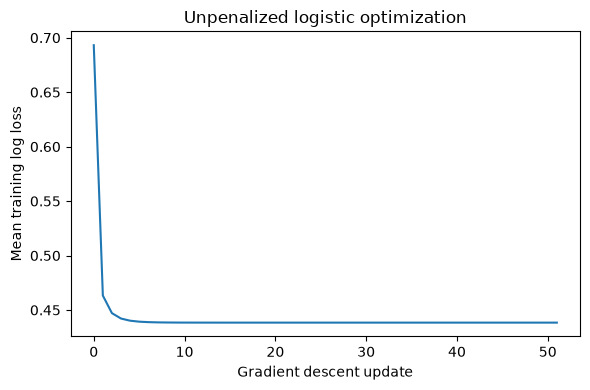

In [3]:
beta_gd = np.zeros(design.shape[1])
step_size = 1 / (np.linalg.norm(design, ord=2) ** 2 / (4 * len(train)))
loss_history = []
max_steps = 20000
for step in range(max_steps + 1):
    loss, gradient = logistic_loss_gradient(beta_gd, design, y_train)
    loss_history.append(loss)
    if np.linalg.norm(gradient) < 1e-8:
        break
    if step < max_steps:
        beta_gd = beta_gd - step_size * gradient
converged = np.linalg.norm(gradient) < 1e-8
assert converged, "Gradient descent reached its iteration limit."

reference = LogisticRegression(C=np.inf, solver="lbfgs", tol=1e-10, max_iter=2000)
reference.fit(Z_train, y_train)
assert reference.n_iter_[0] < reference.max_iter
p_gd = expit(design @ beta_gd)
p_reference = reference.predict_proba(Z_train)[:, 1]
np.testing.assert_allclose(p_gd, p_reference, atol=1e-5)
display(pd.DataFrame({
    "gradient descent": beta_gd,
    "reference": np.r_[reference.intercept_, reference.coef_.ravel()],
}, index=["intercept", *features]))
print("GD updates:", step, "converged:", converged)
print("Final gradient norm:", np.linalg.norm(gradient))
print("Reference iterations:", reference.n_iter_[0])
print("Maximum training probability difference:", np.max(np.abs(p_gd - p_reference)))

plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Gradient descent update")
plt.ylabel("Mean training log loss")
plt.title("Unpenalized logistic optimization")
plt.tight_layout()
plt.show()

## 4. Interpret the unpenalized slopes in original units

**Task:** Translate the fitted coefficients into the original payload, queue, and cache units,
then explain their effect on the estimated probability through **odds**.

Expanding the standardized score gives

$$\beta_0+\sum_j\beta_j\frac{x_j-\mu_j}{a_j}
=b+\sum_jw_jx_j,\qquad
w_j=\frac{\beta_j}{a_j},\qquad b=\beta_0-\sum_jw_j\mu_j.$$

`scaler.scale_` stores $a_j$ and `scaler.mean_` stores $\mu_j$.
`raw_slopes` and `raw_intercept` implement these conversions; they do not fit a new model.
The generating coefficients and these converted estimates are now directly comparable.
They need not agree exactly because we fit only a finite random sample of outcomes.

For probability $p$, **odds** are $p/(1-p)$. For example, $p=0.20$ corresponds to odds
$0.20/0.80=0.25$, or one violation for every four nonviolations in the long run.
Logistic regression models the logarithm of these odds:

$$\log\frac{p}{1-p}=b+\sum_jw_jx_j.$$

Increasing feature $j$ by one original unit, holding the others fixed, therefore multiplies
the odds by $e^{w_j}$. In the saved fit:

- One more payload unit multiplies the odds by about **1.347**.
- One more queued request multiplies the odds by about **1.272**.
- Changing cache from 0 to 1 multiplies the odds by about **0.398**.

An odds multiplier is not a probability multiplier or a percentage-point change.
For example, starting at probability 0.20 (odds 0.25), applying the cache multiplier gives
new odds $0.25\times0.398\approx0.0995$, hence probability
$0.0995/(1+0.0995)\approx0.0905$. The probability change depends on the starting probability.

These coefficients belong to the unpenalized reference fitted in Section 3. Section 5 selects
a possibly regularized model for the later probability and alarm evaluations.

In [4]:
raw_slopes = reference.coef_.ravel() / scaler.scale_
raw_intercept = reference.intercept_[0] - raw_slopes @ scaler.mean_
display(pd.DataFrame({
    "generating coefficient": [-4, 0.35, 0.3, -1.2],
    "fitted coefficient (original units)": np.r_[raw_intercept, raw_slopes],
}, index=["intercept", *features]))
display(pd.DataFrame({"feature": features, "odds multiplier for +1 unit": np.exp(raw_slopes)}))

,generating coefficient,fitted coefficient (original units)
intercept,-4.00,-3.505916
payload,0.35,0.297896
queue,0.30,0.240855
cache,-1.20,-0.920349


,feature,odds multiplier for +1 unit
0,payload,1.347022
1,queue,1.272336
2,cache,0.398380


## 5. Select the slope penalty using training cross-validation

**Task:** Choose how strongly to shrink the standardized slopes using predictions on held-out
training rows. A very flexible fit can follow sampling noise; excessive shrinkage can erase
useful feature effects. The regularization strength is a **hyperparameter**, selected before
the final model fit rather than learned as an ordinary coefficient.

We compare

$$\lambda\in\{0,10^{-4},10^{-3},10^{-2},10^{-1},1\}$$

for the objective from Section 2: mean log loss plus
$\frac{\lambda}{2}\sum_{j=1}^3\beta_j^2$.
The $\beta_j$ are the standardized slopes; the intercept $\beta_0$ is excluded.
We keep the notation $w_j$ from Section 4 for slopes in original units.

### What does `StratifiedKFold` do?

It supplies fitting and scoring row positions for five folds, keeping the class proportions
approximately equal across folds. It does not fit models itself. For each candidate $\lambda$:

1. Hold out 240 of the 1,200 training rows and use the other 960 for fitting.
2. Fit a **fresh scaler on those 960 rows only**, then transform both sets using that scaler.
3. Fit logistic regression on the 960 transformed rows and predict violation probabilities
   for the 240 held-out rows.
4. Compute held-out mean log loss. Repeat until every fold has been held out once.
5. Average the five scores, then choose the $\lambda$ with the smallest average.

Every candidate uses the same folds. Fitting the scaler inside each fold prevents information
from the held-out features entering the fitted preprocessing. Even preprocessing that does not
use labels must follow this rule. Neither validation nor test rows participate.

We score **unpenalized prediction log loss** on the held-out rows: the penalty helps fit the
coefficients, but it is not itself a prediction error. `fold SD` means the standard deviation
of the five scores; it describes their variation and is not a confidence interval.
An exact tie selects the smaller $\lambda$ by grid order.

### Why convert lambda to the library parameter `C`?

Our objective averages the loss over fitting rows. The equivalent library convention can be
written as summed log loss plus $\frac{1}{2C}\sum_{j=1}^3\beta_j^2$. Dividing by the number of fitting
rows $n_{\mathrm{fit}}$ gives the match

$$C=\frac{1}{n_{\mathrm{fit}}\lambda}.$$

Thus larger $\lambda$ means smaller `C`. For $\lambda=0$, `C=np.inf` removes the penalty.
`make_logistic` performs the conversion, using 960 rows for each fold fit and 1,200 for the
final training fit. Keeping the same mathematical penalty requires this size adjustment.
The intercept remains unpenalized.

In the saved run, $\lambda=0.001$ has the lowest average log loss. Its advantage over zero
penalty is tiny, so the table does not establish a decisive benefit from regularization.
We nevertheless follow the specified selection rule and refit on all 1,200 training rows,
using the full-training scaler from Section 2. This produces `selected_model`.
The final gradient check confirms that its coefficients approximately minimize our stated
penalized objective. The fitted model and scaler are kept fixed for the remaining sections.

In [5]:
def make_logistic(penalty, n_fit):
    inverse_penalty = np.inf if penalty == 0 else 1 / (n_fit * penalty)
    return LogisticRegression(C=inverse_penalty, solver="lbfgs", tol=1e-10, max_iter=2000)

lambdas = np.array([0, 1e-4, 1e-3, 1e-2, 1e-1, 1])
folds = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=23).split(X_train, y_train))
cv_rows = []
for penalty in lambdas:
    fold_losses = []
    for fit_rows, score_rows in folds:
        fold_scaler = StandardScaler().fit(X_train[fit_rows])
        X_fit = fold_scaler.transform(X_train[fit_rows])
        X_score = fold_scaler.transform(X_train[score_rows])
        model = make_logistic(penalty, len(fit_rows))
        model.fit(X_fit, y_train[fit_rows])
        assert model.n_iter_[0] < model.max_iter
        probability = model.predict_proba(X_score)[:, 1]
        fold_losses.append(log_loss(y_train[score_rows], probability, labels=[0, 1]))
    cv_rows.append({"lambda": penalty, "CV log loss": np.mean(fold_losses),
                    "fold SD": np.std(fold_losses, ddof=1)})
cv_results = pd.DataFrame(cv_rows)
best_lambda = float(cv_results.loc[cv_results["CV log loss"].idxmin(), "lambda"])
display(cv_results)
print("Frozen lambda:", best_lambda)
selected_model = make_logistic(best_lambda, len(train)).fit(Z_train, y_train)
assert selected_model.n_iter_[0] < selected_model.max_iter

# Check that the reference penalty matches our stated mean-loss objective.
beta_selected = np.r_[selected_model.intercept_, selected_model.coef_.ravel()]
selected_objective, selected_gradient = logistic_loss_gradient(beta_selected, design, y_train, best_lambda)
print("Selected training objective:", selected_objective)
print("Gradient norm under our penalty convention:", np.linalg.norm(selected_gradient))
assert np.linalg.norm(selected_gradient) < 1e-5

,lambda,CV log loss,fold SD
0,0.0000,0.440529,0.024152
1,0.0001,0.440526,0.024132
2,0.0010,0.440503,0.023953
3,0.0100,0.440639,0.022374
4,0.1000,0.451373,0.014649
5,1.0000,0.492122,0.005056


Frozen lambda: 0.001
Selected training objective: 0.4389127597149419
Gradient norm under our penalty convention: 2.6884808808221507e-10


## 6. Audit validation probabilities, then select an alarm threshold

**Task:** Check probability predictions on 400 validation requests, then choose the alarm
cutoff using the relative costs of false alarms and missed violations.

### Probability quality comes before class decisions

We compare the selected model, the unpenalized reference, and the constant training-prevalence
baseline. The first table uses log loss from Section 2 and the **Brier score**:

$$\operatorname{Brier}=\frac{1}{m}\sum_{i=1}^m(p_i-y_i)^2,$$

where $m=400$ is the number of validation rows. Both measures score probabilities directly,
without an alarm threshold; smaller is better. Log loss penalizes confidently wrong predictions
especially strongly. The Brier score is a squared probability error, not a classification error rate.
The validation table is a check; we do not replace the cross-validation-selected penalty with
a different model based on this table.

### What are the possible alarm outcomes?

At threshold $t$, predict an alarm when $p\ge t$.

| Actual outcome | No alarm: predicted 0 | Alarm: predicted 1 |
| --- | --- | --- |
| No violation: actual 0 | True negative (TN) | False positive (FP): false alarm |
| Violation: actual 1 | False negative (FN): missed violation | True positive (TP): detected violation |

Suppose a false alarm costs 1 and a missed violation costs 5, with zero cost for correct decisions.
These are relative cost units, not assumed currency amounts. The empirical mean cost is

$$\text{cost per arrival}=\frac{FP+5FN}{m}.$$

Lowering the threshold raises alarms for more requests: it can catch more violations but
also produces more false alarms. A threshold of 0.5 is not automatically appropriate for these costs.

### Where does the theoretical threshold 1/6 come from?

For this derivation, let $p$ be the true conditional probability of a violation for a given
request. Then $1-p$ is the probability of no violation. **Expected cost** is the cost of
each possible outcome multiplied by its probability, summed over the outcomes.

If we raise an alarm, it costs 1 when there is no violation (a false alarm) and 0 when there
is a violation (a correct alarm):

$$\text{expected cost of alarm}=1\times(1-p)+0\times p=1-p.$$

If we do not raise an alarm, it costs 0 when there is no violation and 5 when there is a
violation (a missed event):

$$\text{expected cost of no alarm}=0\times(1-p)+5\times p=5p.$$

The expression $1\times(1-p)$ is ordinary multiplication: **false-alarm cost times the
probability of no violation**. It is not a function named 1. For example, at $p=0.20$,
an alarm has expected cost $1\times0.80=0.80$, while no alarm has expected cost
$5\times0.20=1.00$. Raising an alarm has the lower expected cost.

Prefer an alarm whenever its expected cost is no larger:

$$1-p\le5p\quad\Longleftrightarrow\quad 1\le6p
\quad\Longleftrightarrow\quad p\ge\frac16.$$

At exactly $p=1/6$, the two actions have equal expected cost; our convention is to raise an alarm.

Using this rule with fitted probabilities assumes they appropriately estimate the conditional
risks and that the stated costs apply. We also select a threshold empirically on validation data.
The grid contains 0.01, 0.02, ..., 0.99, with $1/6$ and 0.5 included explicitly.
For each threshold, the code counts FP and FN and calculates the cost. If several thresholds
tie for minimum cost, it takes the largest one; this favors fewer alarms among tied policies.

The plot shows the resulting validation cost curve. Its minimum occurs at $1/6$ in the saved
run, with cost 0.525 per arrival. An empirical optimum can differ from the theoretical cutoff
because of sampling noise and imperfect probability estimates. Validation chooses only the
threshold, without refitting coefficients. Its minimum cost is a selection result, so we still
need the independent test evaluation to assess the chosen policy.

,log loss,Brier score
model,,
Training prevalence,0.510625,0.164444
Unpenalized reference,0.444179,0.142098
CV-selected model,0.444137,0.142088


Frozen validation-selected threshold: 0.16666666666666666
Minimum validation cost per arrival: 0.525


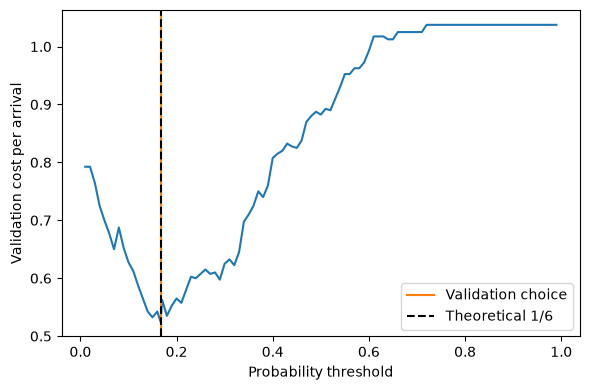

In [6]:
Z_valid = scaler.transform(valid[features].to_numpy())
y_valid = valid["violation"].to_numpy()
p_valid = selected_model.predict_proba(Z_valid)[:, 1]
validation_probabilities = {
    "Training prevalence": np.full(len(valid), baseline_probability),
    "Unpenalized reference": reference.predict_proba(Z_valid)[:, 1],
    "CV-selected model": p_valid,
}
validation_rows = []
for name, probability in validation_probabilities.items():
    validation_rows.append({"model": name,
                            "log loss": log_loss(y_valid, probability, labels=[0, 1]),
                            "Brier score": brier_score_loss(y_valid, probability)})
display(pd.DataFrame(validation_rows).set_index("model"))

thresholds = np.unique(np.r_[np.arange(1, 100) / 100, 1 / 6, 0.5])
threshold_rows = []
for threshold in thresholds:
    prediction = (p_valid >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_valid, prediction, labels=[0, 1]).ravel()
    threshold_rows.append({"threshold": threshold, "total cost": fp + 5 * fn,
                           "cost per arrival": (fp + 5 * fn) / len(valid)})
threshold_results = pd.DataFrame(threshold_rows)
minimum_cost = threshold_results["total cost"].min()
best_threshold = threshold_results.loc[threshold_results["total cost"] == minimum_cost, "threshold"].max()
print("Frozen validation-selected threshold:", best_threshold)
print("Minimum validation cost per arrival:", minimum_cost / len(valid))

plt.figure(figsize=(6, 4))
plt.plot(threshold_results["threshold"], threshold_results["cost per arrival"])
plt.axvline(best_threshold, color="tab:orange", label="Validation choice")
plt.axvline(1 / 6, color="black", linestyle="--", label="Theoretical 1/6")
plt.xlabel("Probability threshold")
plt.ylabel("Validation cost per arrival")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Final test probability and policy evaluations

**Task:** Assess the fixed model and alarm rules on 400 previously unused requests.
No scaler, coefficients, regularization setting, or threshold is learned in this section.
`scaler.transform(...)` applies the training transformation; it does not recalculate means or scales.

The first table evaluates **probabilities** with log loss and Brier score for the same three
prespecified models. In the saved run, selected-model log loss is about 0.436 versus 0.511
for the constant baseline. The unpenalized reference is slightly better than the selected model
on this particular test sample; we report this rather than switching models after seeing the test.

The next table evaluates **alarm policies**, all using the same selected-model probabilities:
threshold 0.5, theoretical threshold $1/6$, and the validation-selected threshold.
Along with the four confusion counts defined in Section 6, it reports

$$\operatorname{precision}=\frac{TP}{TP+FP},\qquad
\operatorname{recall}=\frac{TP}{TP+FN}.$$

**Precision** asks: among alarms, what fraction correspond to actual violations?
**Recall** asks: among actual violations, what fraction did we detect?
The code reports zero if a denominator is zero to avoid undefined display values; such a
value should not be interpreted as an estimate supported by cases that do not exist.
The cost column remains $(FP+5FN)/400$.

For the validation-selected policy in the saved run, the confusion matrix is

| | Predicted 0: no alarm | Predicted 1: alarm |
| --- | --- | --- |
| Actual 0: no violation | TN = 183 | FP = 134 |
| Actual 1: violation | FN = 19 | TP = 64 |

Rows represent actual outcomes; columns represent predicted decisions. Thus

- Precision is $64/(64+134)\approx0.323$: about 32% of alarms correspond to violations.
- Recall is $64/(64+19)\approx0.771$: about 77% of violations are detected.
- Mean cost is $(134+5\times19)/400=0.5725$.

At threshold 0.5, there are only 7 false alarms but 69 missed violations, giving cost
$(7+5\times69)/400=0.880$. The lower threshold produces more false alarms but fewer expensive
misses. It is better under the specified cost, not necessarily under another operational objective.
The theoretical and validation-selected rows coincide here because validation selected exactly $1/6$.

**Check your understanding:** How can a policy have lower precision but lower cost?
Which kind of mistake is weighted more heavily in this experiment?

In [7]:
Z_test = scaler.transform(test[features].to_numpy())
y_test = test["violation"].to_numpy()
p_test = selected_model.predict_proba(Z_test)[:, 1]
print("Test class counts:", test["violation"].value_counts().sort_index().to_dict())
test_probabilities = {
    "Training prevalence": np.full(len(test), baseline_probability),
    "Unpenalized reference": reference.predict_proba(Z_test)[:, 1],
    "CV-selected model": p_test,
}
probability_rows = []
for name, probability in test_probabilities.items():
    probability_rows.append({"model": name,
                             "log loss": log_loss(y_test, probability, labels=[0, 1]),
                             "Brier score": brier_score_loss(y_test, probability)})
test_probability_results = pd.DataFrame(probability_rows).set_index("model")
display(test_probability_results)

policies = {"Threshold 0.5": 0.5, "Theoretical 1/6": 1 / 6,
            "Validation-selected": best_threshold}
policy_rows = []
for name, threshold in policies.items():
    prediction = (p_test >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, prediction, labels=[0, 1]).ravel()
    policy_rows.append({"policy": name, "threshold": threshold,
                        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
                        "precision": precision_score(y_test, prediction, zero_division=0),
                        "recall": recall_score(y_test, prediction, zero_division=0),
                        "cost per arrival": (fp + 5 * fn) / len(test)})
test_policy_results = pd.DataFrame(policy_rows).set_index("policy")
display(test_policy_results)
chosen_matrix = confusion_matrix(y_test, p_test >= best_threshold, labels=[0, 1])
display(pd.DataFrame(chosen_matrix, index=["Actual 0", "Actual 1"],
                     columns=["Predicted 0", "Predicted 1"]))

Test class counts: {0: 317, 1: 83}


,log loss,Brier score
model,,
Training prevalence,0.510625,0.164444
Unpenalized reference,0.436241,0.138653
CV-selected model,0.436342,0.138697


,threshold,TN,FP,FN,TP,precision,recall,cost per arrival
policy,,,,,,,,
Threshold 0.5,0.500000,310,7,69,14,0.666667,0.168675,0.8800
Theoretical 1/6,0.166667,183,134,19,64,0.323232,0.771084,0.5725
Validation-selected,0.166667,183,134,19,64,0.323232,0.771084,0.5725


,Predicted 0,Predicted 1
Actual 0,183,134
Actual 1,19,64


## 8. Test calibration and the precision–recall tradeoff

**Task:** Interpret two complementary diagnostic plots for the already fitted model.
Neither plot is used to change the selected model or threshold.

### Calibration: do the probability values match event frequencies?

A model is **calibrated** if, among requests assigned probability near $p$, approximately a
fraction $p$ actually violate the budget. For example, among many requests assigned probability
0.20, we would expect about 20% violations. Calibration is a property across groups of requests,
not a requirement that one request's binary outcome equal its probability.

`pd.qcut(..., q=8)` sorts test probabilities into eight approximately equal-count groups
called bins. For each bin, the table reports the mean predicted probability, observed violation
fraction (`event_rate`), request count, and number of violations. Here each bin has 50 requests.
The plot compares mean predictions on the horizontal axis with event rates on the vertical axis:

- Near the diagonal: predicted and observed frequencies agree in that bin.
- Above the diagonal: violations are more frequent than predicted; risk is underestimated.
- Below the diagonal: violations are less frequent than predicted; risk is overestimated.

For example, the first saved bin has mean probability about 0.0445 and 2 violations out of 50,
an event rate of 0.04. The last has mean probability about 0.493 and an event rate of 0.60.
With only 50 rows per bin, differences can reflect random variation as well as estimation error.
A binned plot is a diagnostic, not proof of perfect calibration.

### Precision–recall curve: how do decisions change with the threshold?

This curve holds the model fixed and varies the alarm cutoff. Each operating point shows
recall horizontally and precision vertically. Lowering the cutoff cannot reduce recall on a
fixed data set because existing alarms remain alarms; precision can rise or fall as new
requests enter the alarm group. A useful model aims for high precision while detecting a
substantial fraction of violations.

The dashed horizontal line is test prevalence, $83/400=0.2075$. It is the precision obtained
by alarming on every test request, at recall 1, and a reference level for uninformed selection.
The endpoint at recall 0 and precision 1 is a plotting convention, not evidence of useful
alarms with no false positives.

Calibration and ranking are different: probabilities may order requests well while overstating
or understating their risks. The calibration plot checks probability levels; the precision–recall
curve summarizes threshold tradeoffs. We display this **test** curve only to describe performance;
we retain the threshold selected on validation data.

**Check your understanding:** Why does a prediction of 0.20 not become “wrong” simply because
that one request violates the budget? What would you inspect across many similar predictions?

,mean_probability,event_rate,count,events
bin,,,,
"(0.015299999999999998, 0.0622]",0.044535,0.04,50,2
"(0.0622, 0.095]",0.077093,0.08,50,4
"(0.095, 0.128]",0.110739,0.12,50,6
"(0.128, 0.166]",0.145113,0.14,50,7
"(0.166, 0.223]",0.193938,0.16,50,8
"(0.223, 0.288]",0.254720,0.22,50,11
"(0.288, 0.378]",0.331389,0.30,50,15
"(0.378, 0.732]",0.493385,0.60,50,30


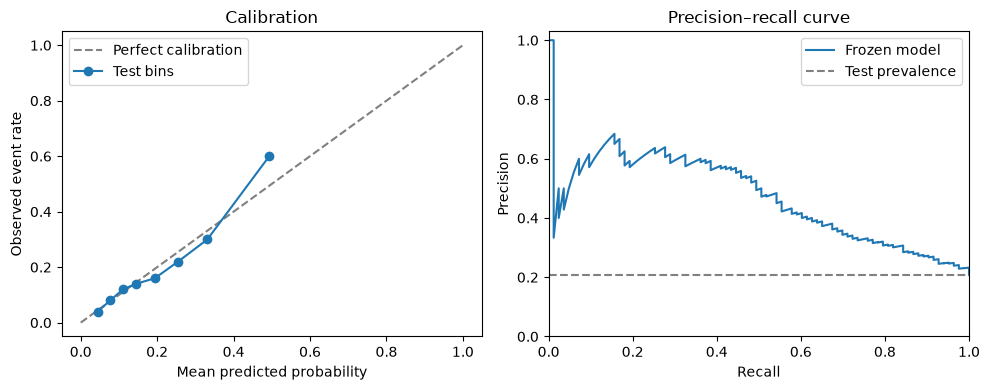

In [8]:
calibration_data = pd.DataFrame({"probability": p_test, "event": y_test})
calibration_data["bin"] = pd.qcut(calibration_data["probability"], q=8, duplicates="drop")
calibration_table = calibration_data.groupby("bin", observed=True).agg(
    mean_probability=("probability", "mean"), event_rate=("event", "mean"),
    count=("event", "size"), events=("event", "sum"))
display(calibration_table)
precision, recall, _ = precision_recall_curve(y_test, p_test)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
axes[0].plot(calibration_table["mean_probability"], calibration_table["event_rate"], "o-", label="Test bins")
axes[0].set(xlabel="Mean predicted probability", ylabel="Observed event rate", title="Calibration")
axes[1].plot(recall, precision, label="Frozen model")
axes[1].axhline(y_test.mean(), color="gray", linestyle="--", label="Test prevalence")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision–recall curve", xlim=(0, 1), ylim=(0, 1.03))
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

## Interpret the results

- The gradient check validates a derivative; the reference-fit comparison validates optimization.
  Neither alone establishes predictive quality.
- Compare log loss and Brier score with the constant baseline. How does a fitted model use the features?
- Explain the change in false alarms and missed events when moving from 0.5 toward 1/6.
  Cost-sensitive prediction is allowed to trade accuracy for fewer expensive errors.
- Validation threshold selection has sampling noise. It need not beat 1/6 on this particular test set.
  Report that outcome rather than changing the selected policy.
- Deviations from the calibration diagonal can reflect sampling noise, estimation error, or a misspecified model.
  This generator is stochastic: even the true probability does not predict every realized label.
- A real arrival-time model could use only information available when the decision must be made.
  The generator's true probability and an observed final latency are not permissible inputs.

**In the saved run:** CV chooses lambda 0.001. Validation selects exactly $1/6$, so
the theoretical and validation-selected test policies coincide. Moving from threshold
0.5 to $1/6$ increases recall from about 0.169 to 0.771 and reduces cost per arrival
from 0.880 to 0.5725, while increasing false positives from 7 to 134. The tradeoff is
explicit in the stated costs; the lower threshold is not better for every objective.